In [1]:
import pandas as pd
import polars as pl
import time
import requests
from pymongo import MongoClient
from pprint import pprint
import psycopg
from pathlib import Path
import pandas as pd
from sqlalchemy import create_engine
import io
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv, find_dotenv
from urllib.parse import urlparse
import psycopg2


In [ ]:
sql = """
WITH notes AS (
  SELECT
    serialnumber,
    STRING_AGG(remarks, ' | ' ORDER BY note_id)      AS remarks_all,
    STRING_AGG(opm_remarks, ' | ' ORDER BY note_id)  AS opm_remarks_all
  FROM d_sale_notes
  GROUP BY serialnumber
)
SELECT
  f.sale_id,
  f.serialnumber,
  f.listyear,
  f.daterecorded,
  f.assessedvalue,
  f.saleamount,
  f.salesratio,

  p.address,
  p.propertytype,
  p.residentialtype,
  p.latitude,
  p.longitude,

  t.town,
  n.nonusecode,

  notes.remarks_all,
  notes.opm_remarks_all
FROM f_sales AS f
JOIN d_property AS p
  ON p.property_id = f.property_id
JOIN d_town AS t
  ON t.town_id = p.town_id
LEFT JOIN d_non_use_code AS n
  ON n.nonusecode_id = f.nonusecode_id
LEFT JOIN notes
  ON notes.serialnumber = f.serialnumber
  LIMIT 10000;
"""


# Recarga .env de forma explícita y sobreescribe variables previas
env_path = find_dotenv(usecwd=True)
load_dotenv(env_path, override=True)

url = os.getenv("DATABASE_URL")
if not url:
    raise RuntimeError("Falta DATABASE_URL en .env")

p = urlparse(url)
print("Conectando a:", p.hostname, p.port)  

# Conecta
conn = psycopg2.connect(url)  # sslmode=require ya va en la URL
cur = conn.cursor()
cur.execute("SELECT current_user, inet_server_addr(), inet_server_port(), now();")
user, ip, port, now = cur.fetchone()
print(f"OK: user={user} ip={ip} port={port} now={now}")

Conectando a: aws-1-eu-west-1.pooler.supabase.com 6543
OK: user=postgres ip=2a05:d018:135e:169a:fbc4:36b0:3b51:648 port=5432 now=2026-02-15 19:26:37.196782+00:00


In [3]:
cur.execute(sql)
rows = cur.fetchall()
cols = [d[0] for d in cur.description]

df_ml = pl.DataFrame(rows, schema=cols)
conn.close()

C:\Users\sebas\AppData\Local\Temp\ipykernel_26064\3272562852.py:5: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  df_ml = pl.DataFrame(rows, schema=cols)


## Exploracion Inicial

In [4]:
print(df_ml.shape)
print(df_ml.head())

(50000, 16)
shape: (5, 16)
┌─────────┬────────────┬──────────┬────────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ sale_id ┆ serialnumb ┆ listyear ┆ daterecord ┆ … ┆ town      ┆ nonusecod ┆ remarks_a ┆ opm_remar │
│ ---     ┆ er         ┆ ---      ┆ ed         ┆   ┆ ---       ┆ e         ┆ ll        ┆ ks_all    │
│ i64     ┆ ---        ┆ i64      ┆ ---        ┆   ┆ str       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ str        ┆          ┆ date       ┆   ┆           ┆ str       ┆ str       ┆ str       │
╞═════════╪════════════╪══════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 1       ┆ 124834     ┆ 2012     ┆ 2013-06-26 ┆ … ┆ MANCHESTE ┆ null      ┆ UNKNOWN   ┆ UNKNOWN   │
│         ┆            ┆          ┆            ┆   ┆ R         ┆           ┆           ┆           │
│ 2       ┆ 30053      ┆ 2003     ┆ 2003-12-02 ┆ … ┆ ELLINGTON ┆ 3         ┆ UNKNOWN   ┆ UNKNOWN   │
│ 9       ┆ 800052     ┆ 2008     ┆ 2008-11-10 ┆ … ┆ SOUTH     ┆

In [5]:
df_ml.describe()

statistic,sale_id,serialnumber,listyear,daterecorded,assessedvalue,saleamount,salesratio,address,propertytype,residentialtype,latitude,longitude,town,nonusecode,remarks_all,opm_remarks_all
str,f64,str,f64,str,f64,f64,f64,str,str,str,f64,f64,str,str,str,str
"""count""",50000.0,"""50000""",50000.0,"""50000""",50000.0,50000.0,50000.0,"""50000""","""50000""","""50000""",15196.0,15196.0,"""50000""","""14117""","""50000""","""50000"""
"""null_count""",0.0,"""0""",0.0,"""0""",0.0,0.0,0.0,"""0""","""0""","""0""",34804.0,34804.0,"""0""","""35883""","""0""","""0"""
"""mean""",96921.87818,null,2011.52384,"""2012-06-06 21:05:04.128000""",274146.70978,401823.598371,3.341481,null,null,null,41.496761,-72.87685,null,null,null,null
"""std""",56063.947041,null,7.081861,null,1.2112e6,2.1273e6,224.140023,null,null,null,0.264322,0.449988,null,null,null,null
"""min""",1.0,"""100005""",2001.0,"""0023-12-05""",0.0,0.0,0.0,"""0 APRIL WAY""","""Apartments""","""Condo""",34.34589,-89.50163,"""ANDOVER""","""01 - Family""","""""BROADCAST HOUSE"" | UNKNOWN""",""".33 ACRES NOT ASSESSED AS BUIL…"
"""25%""",48419.0,null,2005.0,"""2005-11-04""",89480.0,147000.0,0.4716,null,null,null,41.28815,-73.18539,null,null,null,null
"""50%""",96981.0,null,2012.0,"""2012-11-14""",141650.0,238500.0,0.6,null,null,null,41.49892,-72.900738,null,null,null,null
"""75%""",145605.0,null,2018.0,"""2019-06-27""",232870.0,386000.0,0.758545,null,null,null,41.7123,-72.63327,null,null,null,null
"""max""",193930.0,"""99515""",2023.0,"""2024-09-30""",1.10670208e8,3.955e8,49660.0,"""ZENITH LN""","""Vacant Land""","""UNKNOWN""",42.045053,-71.789532,"""WOODSTOCK""","""9""","""way below market - SALE PRICE …","""VERY POOR CONDITION | UNKNOWN …"


## Limpieza Inicial

In [6]:
df_ml.select(pl.all().null_count())

sale_id,serialnumber,listyear,daterecorded,assessedvalue,saleamount,salesratio,address,propertytype,residentialtype,latitude,longitude,town,nonusecode,remarks_all,opm_remarks_all
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,34804,34804,0,35883,0,0


In [7]:
df_ml = df_ml.with_columns(pl.col("nonusecode").fill_null("UKNOWN"))
df_ml = df_ml.with_columns(pl.col("latitude").fill_null(0))
df_ml = df_ml.with_columns(pl.col("longitude").fill_null(0))

df_ml = df_ml.filter(pl.col("salesratio").is_not_null() & pl.col("daterecorded").is_not_null())

In [8]:
df_ml.head(2)

sale_id,serialnumber,listyear,daterecorded,assessedvalue,saleamount,salesratio,address,propertytype,residentialtype,latitude,longitude,town,nonusecode,remarks_all,opm_remarks_all
i64,str,i64,date,f64,f64,f64,str,str,str,f64,f64,str,str,str,str
1,"""124834""",2012,2013-06-26,103000.0,141250.0,0.729204,"""113 WADDELL ROAD""","""Two Family""","""Two Family""",0.0,0.0,"""MANCHESTER""","""UKNOWN""","""UNKNOWN""","""UNKNOWN"""
2,"""30053""",2003,2003-12-02,66450.0,30000.0,2.215,"""35 GRAND BLVD""","""UNKNOWN""","""UNKNOWN""",0.0,0.0,"""ELLINGTON""","""3""","""UNKNOWN""","""UNKNOWN"""


In [9]:
import polars as pl

# 1) Regenera año y mes directamente desde la fecha
df_ml = df_ml.with_columns([
    pl.col("daterecorded").dt.year().alias("sale_year"),
    pl.col("daterecorded").dt.month().alias("sale_month_num"),   # 1..12 numérico
])


df_ml = df_ml.with_columns(
    pl.col("daterecorded").dt.strftime("%b").alias("sale_month_name") 
).with_columns(
    pl.col("sale_month_name").cast(pl.Categorical)
)

df_ml = df_ml.drop(["sale_month", "sale_month_cat"], strict=False) \
             .rename({"sale_month_name": "sale_month"})

In [24]:
num_cols = [c for c, dt in df_ml.schema.items() if dt in (pl.Int64, pl.Float64, pl.Int32)]
cat_cols = [c for c, dt in df_ml.schema.items() if dt in (pl.Utf8, pl.Categorical)]

### ANALISIS DESCRIPTIVO

In [25]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def qqplot_col(df: pl.DataFrame, col: str, log=False):
    x = df[col].drop_nulls().to_numpy()
    if x.size == 0:
        print(f"[{col}] sin datos."); return
    if log:
        x = np.log1p(x)
        title = f"QQ-plot {col} (log1p)"
    else:
        title = f"QQ-plot {col}"
    stats.probplot(x, dist="norm", plot=plt)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [26]:
def hist_box_log(df, col):
    x = df[col].drop_nulls().to_numpy()
    x = np.log1p(x)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,5),
                                   gridspec_kw={"height_ratios":[3,1]},
                                   sharex=True)

    ax1.hist(x, bins="auto", color="#2a9d8f")
    ax1.set_title(f"{col} (log1p transform)")
    ax2.boxplot(x, vert=False)

    plt.tight_layout()
    plt.show()

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

def hist_box_by_cat(df, y, cat, top=10):
    d = df.filter(pl.col(y).is_not_null() & pl.col(cat).is_not_null()) \
          .select([y, cat])

    cats = (d.group_by(cat).len().sort("len", descending=True)
              .head(top).get_column(cat).to_list())

    d = d.filter(pl.col(cat).is_in(cats)).to_pandas()
    d[y] = np.log1p(d[y]) 

    # --- HISTOGRAMA ---
    plt.figure(figsize=(10,4))
    sns.histplot(data=d, x=y, hue=cat, element="step", stat="density", common_norm=False)
    plt.title(f"{y} (log1p) - hist por {cat}")
    plt.tight_layout()
    plt.show()

    # --- BOX PLOT ---
    plt.figure(figsize=(10,4))
    sns.boxplot(data=d, x=cat, y=y, hue=cat, dodge=False, fliersize=1)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{y} (log1p) - boxplot por {cat}")
    plt.tight_layout()
    plt.show()

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl

def bar_by_cat(df, y, cat, top=20):
    d = df.filter(
            pl.col(y).is_not_null() & pl.col(cat).is_not_null()
        ).select([y, cat])

    cats = (d.group_by(cat).len()
              .sort("len", descending=True)
              .head(top)
              .get_column(cat).to_list())

    d = d.filter(pl.col(cat).is_in(cats)).to_pandas()

    order = d.groupby(cat)[y].mean().sort_values(ascending=False).index

    # Plot
    plt.figure(figsize=(10,4))
    sns.barplot(data=d, x=cat, y=y, order=order,
                color="#2a9d8f", estimator="mean")
    plt.yscale("log")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## <font color='#3d59c6'>  **Variables objetivo** </font>

In [29]:
print(df_ml.select(pl.col("saleamount")).describe())
print(df_ml.select("saleamount").std())
print(df_ml.select("saleamount").var() )

shape: (9, 2)
┌────────────┬───────────────┐
│ statistic  ┆ saleamount    │
│ ---        ┆ ---           │
│ str        ┆ f64           │
╞════════════╪═══════════════╡
│ count      ┆ 50000.0       │
│ null_count ┆ 0.0           │
│ mean       ┆ 401823.598371 │
│ std        ┆ 2.1273e6      │
│ min        ┆ 0.0           │
│ 25%        ┆ 147000.0      │
│ 50%        ┆ 238500.0      │
│ 75%        ┆ 386000.0      │
│ max        ┆ 3.955e8       │
└────────────┴───────────────┘
shape: (1, 1)
┌────────────┐
│ saleamount │
│ ---        │
│ f64        │
╞════════════╡
│ 2.1273e6   │
└────────────┘
shape: (1, 1)
┌────────────┐
│ saleamount │
│ ---        │
│ f64        │
╞════════════╡
│ 4.5253e12  │
└────────────┘


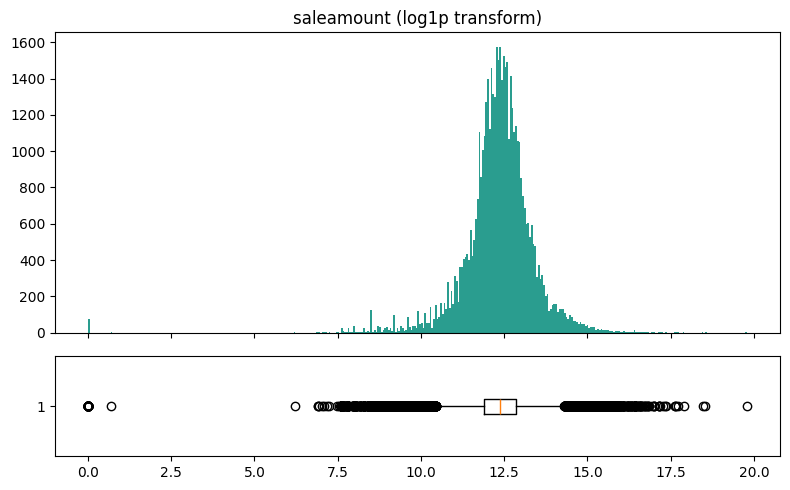

In [30]:
hist_box_log(df_ml, "saleamount")

In [31]:
print(df_ml.select("saleamount").std())
print(df_ml.select("saleamount").var() )

shape: (1, 1)
┌────────────┐
│ saleamount │
│ ---        │
│ f64        │
╞════════════╡
│ 2.1273e6   │
└────────────┘
shape: (1, 1)
┌────────────┐
│ saleamount │
│ ---        │
│ f64        │
╞════════════╡
│ 4.5253e12  │
└────────────┘


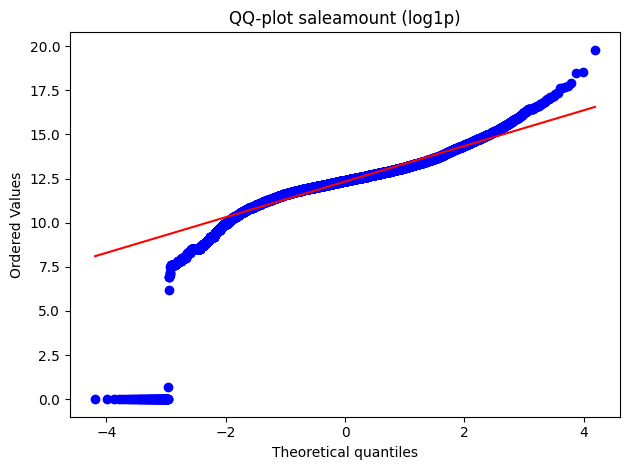

In [32]:
qqplot_col(df_ml, "saleamount", log=True) 

# Diagnóstico con town

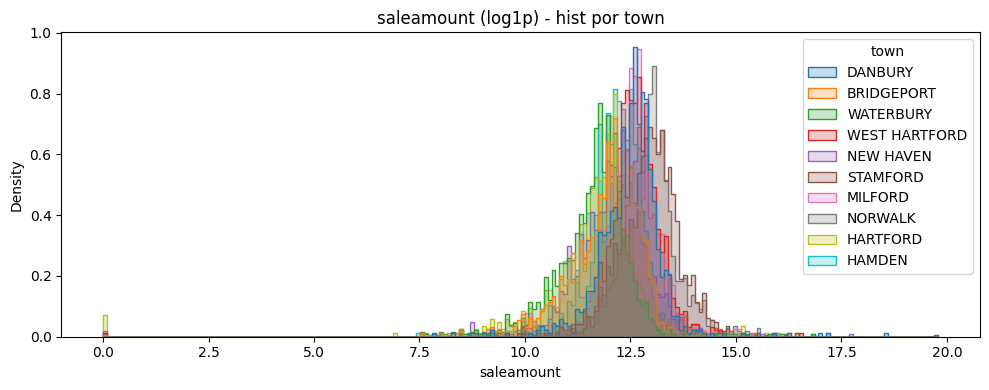

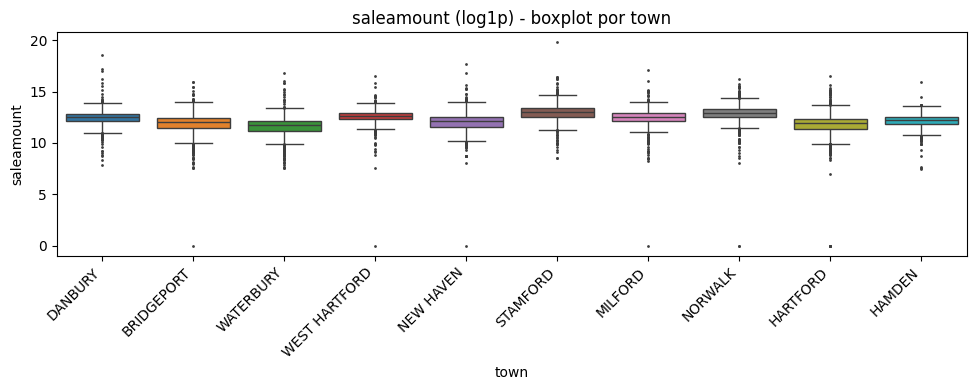

In [33]:
hist_box_by_cat(df_ml, "saleamount", "town")

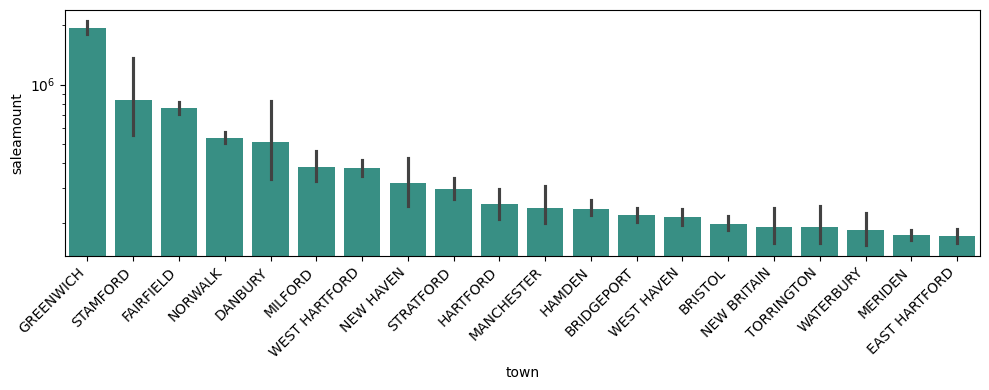

In [34]:
bar_by_cat(df_ml, "saleamount", "town")

## Numeric

In [35]:
num_cols = [c for c in num_cols if c not in ["sale_id", "saleamount"]]
df_ml.select(pl.col(num_cols)).describe()

statistic,listyear,assessedvalue,salesratio,latitude,longitude,sale_year
str,f64,f64,f64,f64,f64,f64
"""count""",50000.0,50000.0,50000.0,50000.0,50000.0,50000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2011.52384,274146.70978,3.341481,12.611696,-22.148732,2011.90652
"""std""",7.081861,1.2112e6,224.140023,19.087121,33.520852,27.601455
"""min""",2001.0,0.0,0.0,0.0,-89.50163,23.0
"""25%""",2005.0,89480.0,0.4716,0.0,-72.5079,2005.0
"""50%""",2012.0,141650.0,0.6,0.0,0.0,2012.0
"""75%""",2018.0,232870.0,0.758545,41.22112,0.0,2019.0
"""max""",2023.0,1.10670208e8,49660.0,42.045053,0.0,2024.0


In [36]:
for col in num_cols:
    stats = df_ml.select([
        pl.col(col).std().alias("std"),
        pl.col(col).var().alias("var")
    ])
    print(f"\nColumna: {col}")
    print(stats)



Columna: listyear
shape: (1, 2)
┌──────────┬───────────┐
│ std      ┆ var       │
│ ---      ┆ ---       │
│ f64      ┆ f64       │
╞══════════╪═══════════╡
│ 7.081861 ┆ 50.152755 │
└──────────┴───────────┘

Columna: assessedvalue
shape: (1, 2)
┌──────────┬───────────┐
│ std      ┆ var       │
│ ---      ┆ ---       │
│ f64      ┆ f64       │
╞══════════╪═══════════╡
│ 1.2112e6 ┆ 1.4670e12 │
└──────────┴───────────┘

Columna: salesratio
shape: (1, 2)
┌────────────┬──────────────┐
│ std        ┆ var          │
│ ---        ┆ ---          │
│ f64        ┆ f64          │
╞════════════╪══════════════╡
│ 224.140023 ┆ 50238.749981 │
└────────────┴──────────────┘

Columna: latitude
shape: (1, 2)
┌───────────┬────────────┐
│ std       ┆ var        │
│ ---       ┆ ---        │
│ f64       ┆ f64        │
╞═══════════╪════════════╡
│ 19.087121 ┆ 364.318174 │
└───────────┴────────────┘

Columna: longitude
shape: (1, 2)
┌───────────┬─────────────┐
│ std       ┆ var         │
│ ---       ┆ ---     

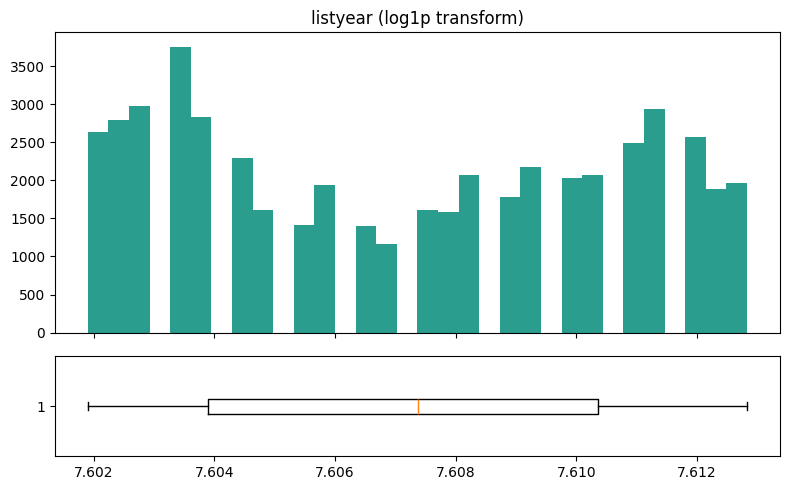

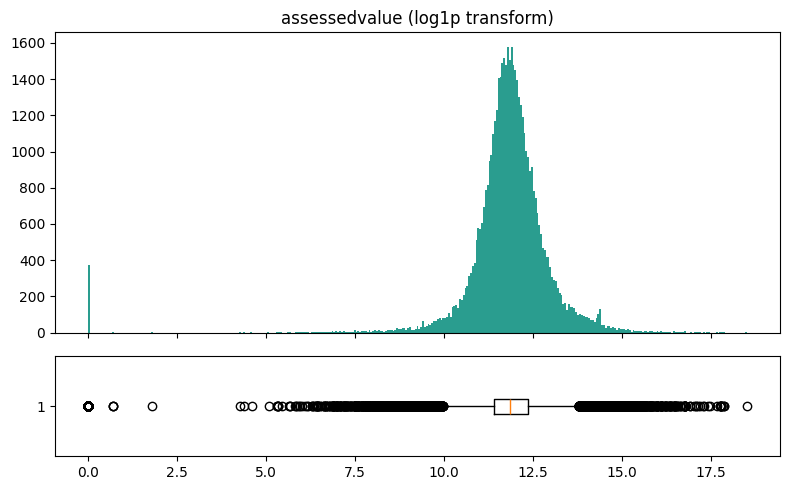

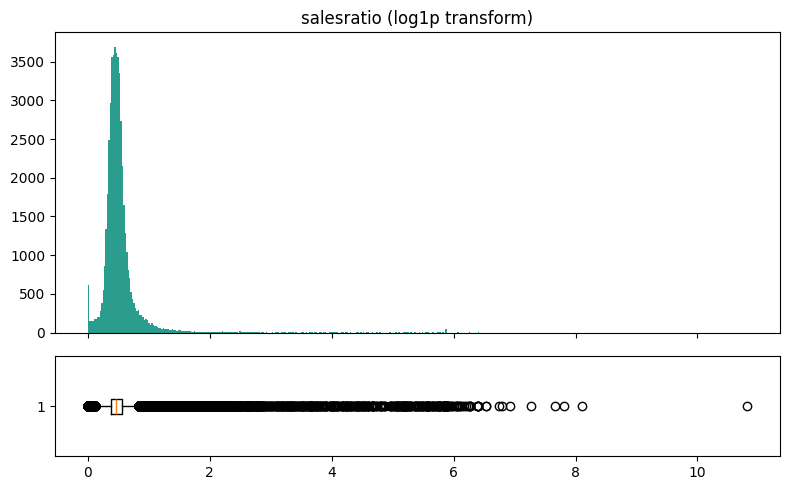

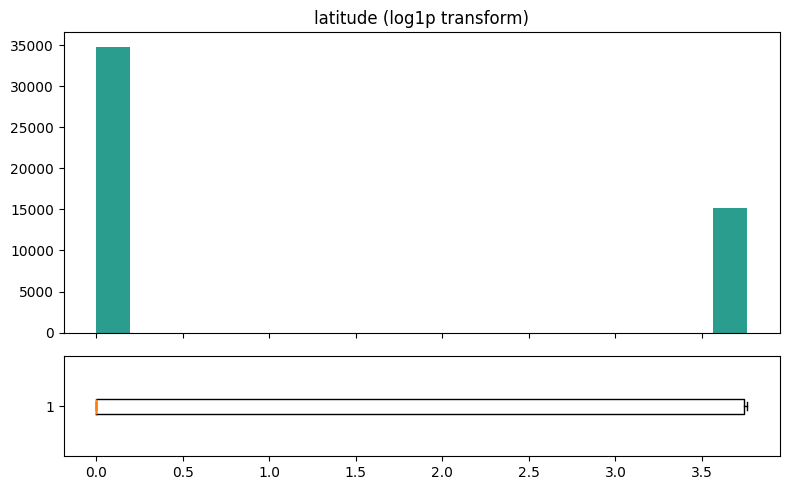

C:\Users\sebas\AppData\Local\Temp\ipykernel_26064\222074329.py:3: RuntimeWarning: invalid value encountered in log1p
  x = np.log1p(x)


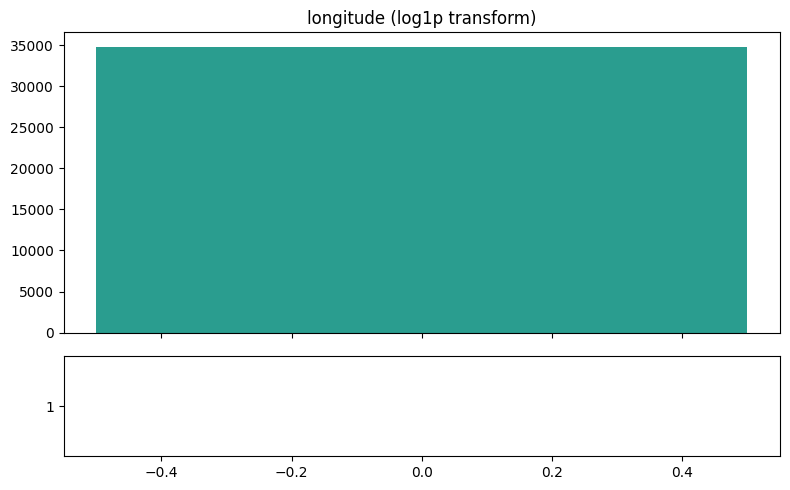

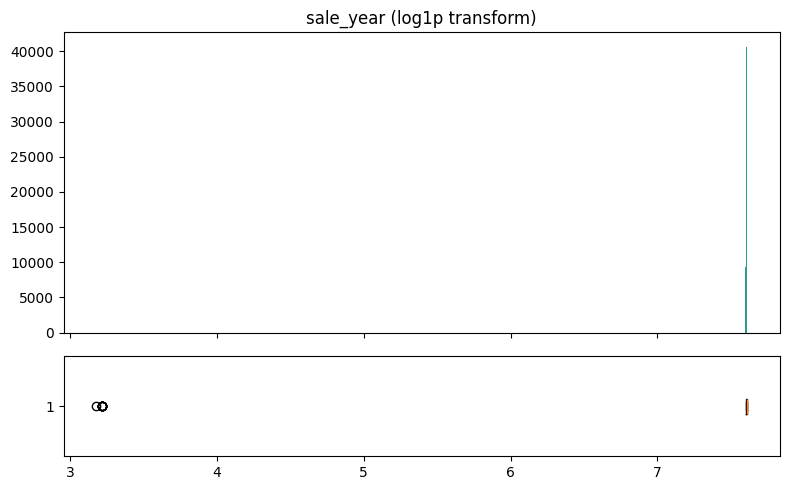

In [37]:
for col in num_cols:
    hist_box_log(df_ml, col)

#### <font color='#3d59c6'>  **ANÁLISIS BIVARIANTE Numéricas vs objetivo** </font>

In [38]:
def corr_vs_target(df, target, num_cols):
    cols = [c for c in num_cols if c != target]
    corr = df.select([pl.corr(c, target).alias(c) for c in cols])
    return (corr.transpose(include_header=True, header_name="feature")
                 .rename({"column_0": "corr"})
                 .sort("corr", descending=True))

# Ejemplo de uso:
corr_tbl = corr_vs_target(df_ml, "saleamount", num_cols)
corr_tbl

feature,corr
str,f64
"""assessedvalue""",0.262898
"""listyear""",0.032955
"""latitude""",0.015442
"""sale_year""",0.008841
"""salesratio""",-0.002242
"""longitude""",-0.016038


## Categóricas

In [39]:
def freq_tables(df, cat_cols):
    for c in cat_cols:
        n = df[c].n_unique()
        if n <= 2: 
            continue
        tab = (
            df.group_by(c).len().rename({"len":"obs"})
              .sort("obs", descending=True)
              .with_columns((pl.col("obs") * 100 / pl.col("obs").sum()).alias("perc"))
        )
        print(f"\n {c} ({n} categorías)")
        print(tab)

In [40]:
freq_tables(df_ml, cat_cols)


 serialnumber (12847 categorías)
shape: (12_847, 3)
┌──────────────┬─────┬───────┐
│ serialnumber ┆ obs ┆ perc  │
│ ---          ┆ --- ┆ ---   │
│ str          ┆ u32 ┆ f64   │
╞══════════════╪═════╪═══════╡
│ 10060        ┆ 38  ┆ 0.076 │
│ 20035        ┆ 38  ┆ 0.076 │
│ 10013        ┆ 35  ┆ 0.07  │
│ 20025        ┆ 35  ┆ 0.07  │
│ 40041        ┆ 35  ┆ 0.07  │
│ …            ┆ …   ┆ …     │
│ 101118       ┆ 1   ┆ 0.002 │
│ 1500861      ┆ 1   ┆ 0.002 │
│ 124542       ┆ 1   ┆ 0.002 │
│ 18449        ┆ 1   ┆ 0.002 │
│ 1500542      ┆ 1   ┆ 0.002 │
└──────────────┴─────┴───────┘

 address (45659 categorías)
shape: (45_659, 3)
┌───────────────────────┬─────┬───────┐
│ address               ┆ obs ┆ perc  │
│ ---                   ┆ --- ┆ ---   │
│ str                   ┆ u32 ┆ f64   │
╞═══════════════════════╪═════╪═══════╡
│ 8 SOUTH RD            ┆ 148 ┆ 0.296 │
│ MULTI ADDRESSES       ┆ 21  ┆ 0.042 │
│ RIGGS ST              ┆ 18  ┆ 0.036 │
│ 166 OLD BROOKFIELD RD ┆ 15  ┆ 0.03  │
│ 50 AIKEN S

#### <font color='#3d59c6'>  **ANÁLISIS BIVARIANTE Categóricas vs objetivo** </font>

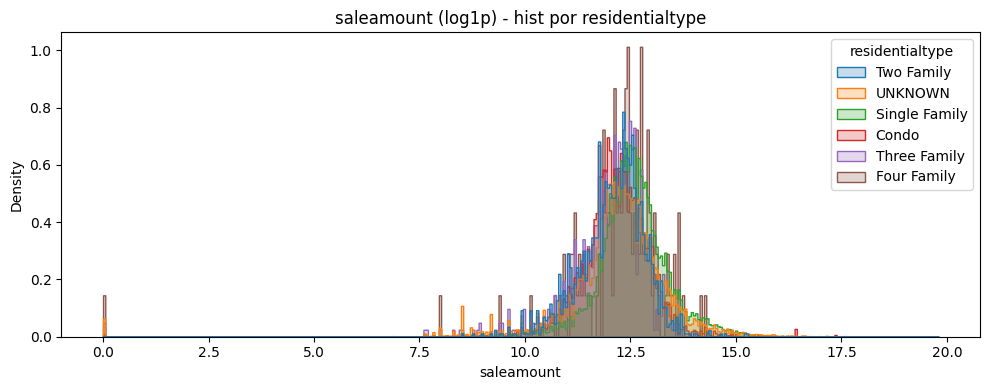

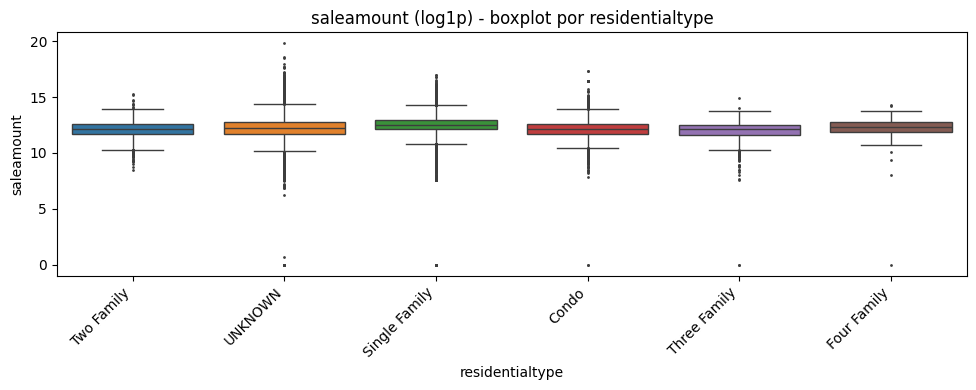

In [41]:
hist_box_by_cat(df_ml, "saleamount", "residentialtype")

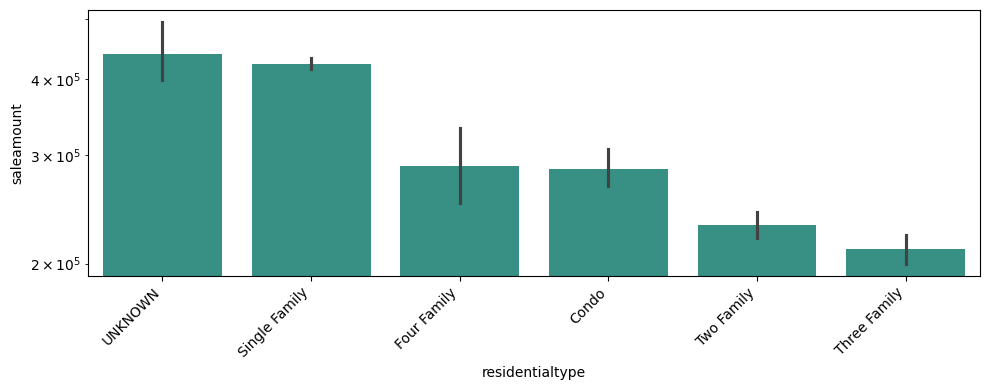

In [42]:
bar_by_cat(df_ml, "saleamount", "residentialtype")

C:\Users\sebas\AppData\Local\Temp\ipykernel_26064\3364710883.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = d.groupby(cat)[y].mean().sort_values(ascending=False).index


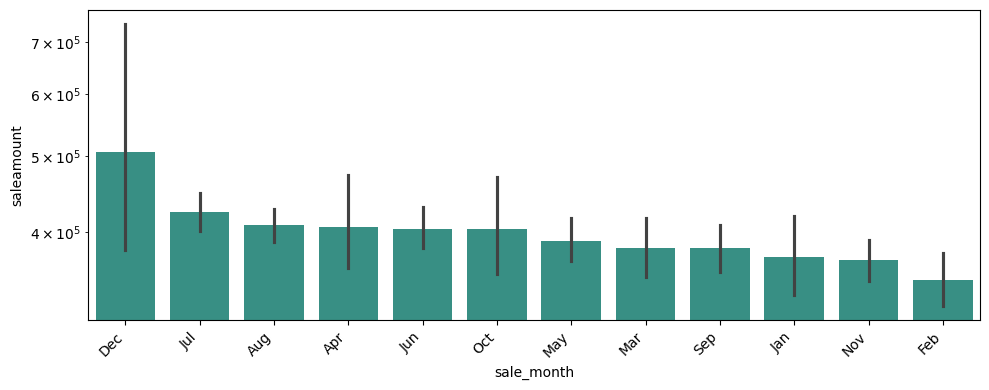

In [43]:
bar_by_cat(df_ml, "saleamount", "sale_month")

## Anova

In [44]:
#from scipy.stats import f_oneway
#
#def anova_cat(df, y, cat):
#    d = df.select([y, cat]).drop_nulls().to_pandas()
#    groups = [g[y].values for _, g in d.groupby(cat)]
#    return f_oneway(*groups)
#
#for c in cat_cols:
#    print(c)
#    print(anova_cat(df_ml, "saleamount", c))

## Correlaciones

In [45]:

def corr_matrix(df, num_cols, method="pearson"):
    return df.select(num_cols).to_pandas().corr(method=method)

def corr_heatmap(df, num_cols, method="pearson"):
    C = corr_matrix(df, num_cols, method)
    mask = np.triu(np.ones_like(C, dtype=bool))
    plt.figure(figsize=(0.6*len(C), 0.6*len(C)))
    sns.heatmap(C, mask=mask, cmap="vlag", center=0, linewidths=.5)
    plt.title(f"Correlación ({method})")
    plt.tight_layout(); plt.show()
    return C


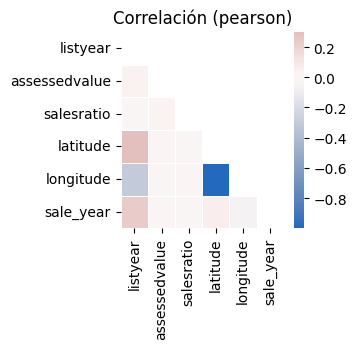

In [46]:
C = corr_heatmap(df_ml, num_cols, method="pearson")